# Load Landsat Collection 2 Level-2 data from the Planetary Computer STAC catalog

This notebook shows an example of loading Landsat Collection 2 Level-2 data from the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/).

## Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).


In [1]:
import matplotlib.pyplot as plt
import xarray as xr
from xcube.core.store import get_data_store_params_schema, new_data_store
from xcube_resampling.utils import reproject_bbox


In [2]:
xr.set_options(display_expand_attrs=False)


There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/):

- **`stac-pc-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-pc`**: Enables you to open individual STAC items.


---
## Data store to access spatiotemporal analysis-ready data cubes


In [3]:
store_params = get_data_store_params_schema("stac-pc-ardc")
store_params


In [4]:
store = new_data_store("stac-pc-ardc")


In [5]:
store.list_data_ids()


['sentinel-2-l2a',
 'sentinel-3-synergy-syn-l2-netcdf',
 'sentinel-3-slstr-lst-l2-netcdf',
 'landsat-c2-l2',
 'hls2-l30',
 'hls2-s30']

In [6]:
store.get_open_data_params_schema("landsat-c2-l2")


The following example opens a Landsat data cube over the greater Hamburg area for July 2024. We request the red, green, blue, and thermal infrared band `lwir11`.


In [7]:
ds = store.open_data(
    data_id="landsat-c2-l2",
    bbox=[9.7, 53.3, 10.3, 53.8],
    time_range=["2026-06-24", "2026-07-08"],
    spatial_res=30 / 111320,
    crs="EPSG:4326",
    asset_names=["red", "green", "blue", "lwir11", "qa_pixel"],
)
ds


/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/ar

<xarray.Dataset> Size: 298MB
Dimensions:      (time: 4, lon: 2227, lat: 1856)
Coordinates:
  * time         (time) datetime64[ns] 32B 2026-06-24T10:20:32.673286 ... 202...
  * lon          (lon) float64 18kB 9.7 9.7 9.701 9.701 ... 10.3 10.3 10.3 10.3
  * lat          (lat) float64 15kB 53.8 53.8 53.8 53.8 ... 53.3 53.3 53.3 53.3
    spatial_ref  int64 8B 0
Data variables:
    red          (time, lat, lon) float32 66MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    green        (time, lat, lon) float32 66MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    blue         (time, lat, lon) float32 66MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    lwir11       (time, lat, lon) float32 66MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
    qa_pixel     (time, lat, lon) uint16 33MB dask.array<chunksize=(1, 1856, 2048), meta=np.ndarray>
Attributes: (5)

We can mask clouds in the Surface Temperature band using the `qa_pixel` Quality Assessment band.

In [8]:
qa = ds["qa_pixel"]
invalid = (
    ((qa & 1) != 0)     # fill
    | ((qa & 2) != 0)   # dilated cloud
    | ((qa & 4) != 0)   # cirrus
    | ((qa & 8) != 0)   # cloud
    | ((qa & 16) != 0)  # cloud shadow
)
ds["lwir11"] = ds["lwir11"].where(~invalid)

We can plot the red and land surface temperature band (`lwir11`) side by side for one time stamp as an example.

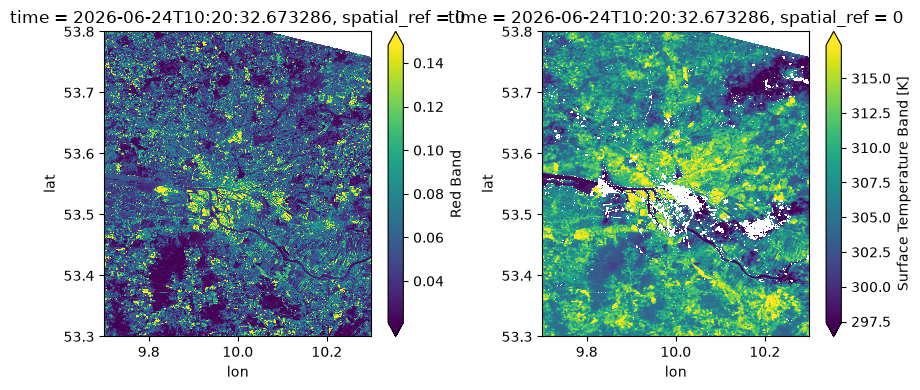

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ds.red.isel(time=0).plot(ax=ax[0], robust=True)
ds.lwir11.isel(time=0).plot(ax=ax[1], robust=True)
plt.tight_layout()
plt.show()

We can also request the same data cube in a different CRS. Note that the bounding box and the spatial resolution needs to be given in the requested CRS.

In [10]:
bbox = [9.7, 53.3, 10.3, 53.8]
crs_target = "EPSG:32632"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_target)

ds_utm = store.open_data(
    data_id="landsat-c2-l2",
    bbox=bbox_utm,
    time_range=["2026-06-24", "2026-07-08"],
    spatial_res=30,
    crs=crs_target,
    asset_names=["red", "green", "blue", "lwir11"],
)
ds_utm


/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
/home/konstantin/micromamba/envs/xcube-stac/lib/python3.13/site-packages/dask/ar

<xarray.Dataset> Size: 162MB
Dimensions:      (time: 4, y: 1873, x: 1351)
Coordinates:
  * time         (time) datetime64[ns] 32B 2026-06-24T10:20:32.673286 ... 202...
  * y            (y) float64 15kB 5.962e+06 5.962e+06 ... 5.906e+06 5.906e+06
  * x            (x) float64 11kB 5.461e+05 5.462e+05 ... 5.866e+05 5.866e+05
    spatial_ref  int64 8B 0
Data variables:
    red          (time, y, x) float32 40MB dask.array<chunksize=(1, 1873, 1351), meta=np.ndarray>
    green        (time, y, x) float32 40MB dask.array<chunksize=(1, 1873, 1351), meta=np.ndarray>
    blue         (time, y, x) float32 40MB dask.array<chunksize=(1, 1873, 1351), meta=np.ndarray>
    lwir11       (time, y, x) float32 40MB dask.array<chunksize=(1, 1873, 1351), meta=np.ndarray>
Attributes: (5)

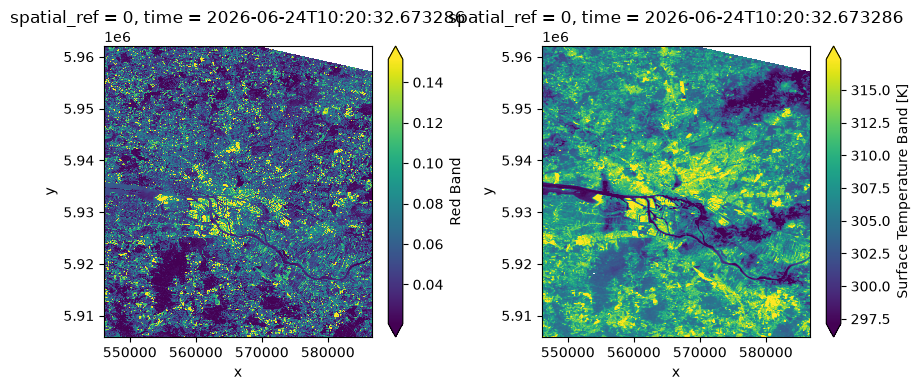

CPU times: user 5.04 s, sys: 469 ms, total: 5.51 s
Wall time: 18.3 s


In [11]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ds_utm.red.isel(time=0).plot(ax=ax[0], robust=True)
ds_utm.lwir11.isel(time=0).plot(ax=ax[1], robust=True)
plt.tight_layout()
plt.show()

---
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile.


In [12]:
store = new_data_store("stac-pc")


In [13]:
store.get_search_params_schema()


In [14]:
descriptors = list(
    store.search_data(
        collections=["landsat-c2-l2"],
        bbox=[8.8, 41.8, 9.2, 42.2],
        time_range=["2024-07-19", "2024-07-25"],
    )
)
[d.to_dict() for d in descriptors]


[{'data_id': 'collections/landsat-c2-l2/items/LC08_L2SP_193031_20240723_02_T1',
  'data_type': 'dataset',
  'bbox': [7.573652562312779,
   40.680314965998555,
   10.421463406616004,
   42.81197503400144],
  'time_range': ('2024-07-23T10:05:20.838660Z', None)}]

In [15]:
store.get_open_data_params_schema(data_id=descriptors[0].data_id)


In [16]:
ds = store.open_data(
    data_id=descriptors[0].data_id,
    asset_names=["lwir11"],
    apply_scaling=True,
)
ds


<xarray.Dataset> Size: 245MB
Dimensions:      (x: 7761, y: 7891)
Coordinates:
  * x            (x) float64 62kB 3.834e+05 3.834e+05 ... 6.162e+05 6.162e+05
  * y            (y) float64 63kB 4.741e+06 4.741e+06 ... 4.504e+06 4.504e+06
    spatial_ref  int64 8B 0
Data variables:
    lwir11       (y, x) float32 245MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (3)

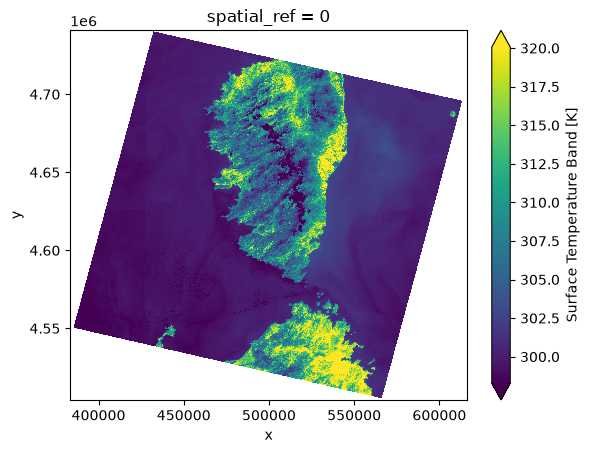

In [17]:
ds.lwir11[::3, ::3].plot(robust=True)
